# Bayesian Inference Example: Beta-Binomial Model

The purpose of this notebook is to understand how Bayesian statistical inference works from end-to-end. In this notebook, we will go over the following items:

- How to visulize your dataset
- How to choose an appropriate Bayesian model using a prior-predictive check
- How to conduct Bayesian inference: conjugate vs. non-conjugate case
- How to verify that your Bayesian model is well-calibrated using a posterior-predictive check
- How to extract Bayesian estimators
- How to obtain predictions

Setup:

In [ ]:
import numpy as np
import scipy.stats as sp
import matplotlib.pyplot as plt
import seaborn as sns

# Set the numpy random seed
np.random.seed(0)

## Beta-Binomial Model

Before working with real data, let's work with a simulated example to understand how Bayesian inference works. Let's assume the following probabilistic model for the data generating process:

\begin{equation*}
X_i \sim \mathrm{Binomial}(N, \pi)
\end{equation*}

That is, we assume that the random sample is Binomial distribution with $N$ Bernoulli trials per sample and probability of success $\pi$. To begin, let's write a function to simulate some data from this model.

In [ ]:

# Function to simulate from a binomial distribuition
def generate_binomial_data(num_data, num_trials, success_probability):
  return np.random.binomial(n=num_trials, p=success_probability, size=num_data)

We can now generate some data with some ground truth parameters:

$$n=100$$
$$N=20$$
$$\pi=0.3$$

In [ ]:
num_trials = 25
success_probability = 0.3

x = generate_binomial_data(num_data=3, num_trials=num_trials, success_probability=success_probability)

Let's histogram the data to see what it looks like:

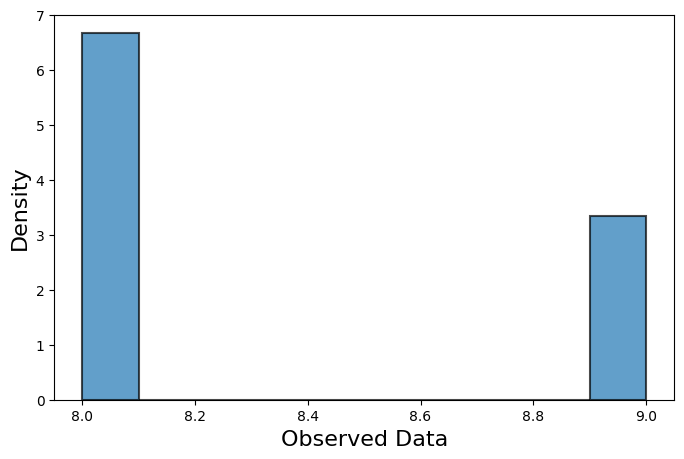

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(x, bins=10, density=True, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.xlabel('Observed Data', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.show()

### Prior-Predictive Check

Before doing any inference, we want to make sure that the class of priors considered can accurately capture the data generating process. For this model, we will restrict the class of priors to Beta distributions (for conjugacy):
\begin{equation*}
\pi \sim \mathrm{Beta}(\alpha_0, \beta_0)
\end{equation*}
The following lines of code show the prior-predictive check as a function of the prior hyperparameters $\alpha_0$ and $\beta_0$

In [ ]:
def beta_binomial_predictive(alpha, beta, label, color, size=10000):
  # Draw samples from beta distribution
  parameter_samples = np.random.beta(a=alpha, b=beta, size=size)
  # Simulate data from corresponding samples
  simulated_data = np.random.binomial(n=num_trials, p=parameter_samples)
  # KDE plot of simulated data
  sns.kdeplot(simulated_data, color=color, linewidth=3, label=label, bw_adjust=2, cut=0)


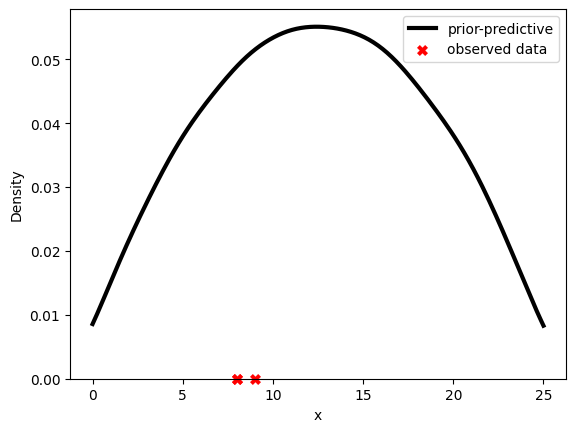

In [ ]:
  alpha_0 = 2
  beta_0 = 2

  beta_binomial_predictive(alpha=alpha_0, beta=beta_0,
                           label='prior-predictive', color='black', size=100000)
  plt.xlabel('x')
  # Scatter plot of observed data to make sure it is well covered
  ax = plt.scatter(x, np.zeros(x.shape), color='red', marker='X', s=60, linewidths=0.1, label='observed data')
  plt.legend()
  ax.set_clip_on(False)
  plt.show()

We can see that for small values of $\alpha_0$ and $\beta_0$, the observed count data well covered by the prior-predictive density.

### Posterior Computation

We now want to perform Bayesian inference and see if the posterior-predictive distribution is better covered. Recall that the Beta distribution is a conjugate prior for a Binomial likelihood function, and therefore, the posterior can be analytically computed as another Beta distribution, with updated parameters as follows:

\begin{align*}
&X_i \sim \mathrm{Binomial}(N, \pi) \\
&\pi \sim \mathrm{Beta}(\alpha_0, \beta_0) \\
&\pi|x_{1:n} \sim \mathrm{Beta}(\alpha_n, \beta_n)
\end{align*}
where $\alpha_n$ and $\beta_n$ are given by:
\begin{align*}
&\alpha_n =  \alpha_0 + \sum_{i=1}^n x_i\\
&\beta_n =  \beta_0 + Nn - \sum_{i=1}^n x_i\\
\end{align*}

In [ ]:
alpha_n = alpha_0 + np.sum(x)
beta_n = beta_0 + num_trials*x.shape[0] - np.sum(x)

Now that we have computed the posterior hyperparameters, we can plot the posterior and compare it to the prior:

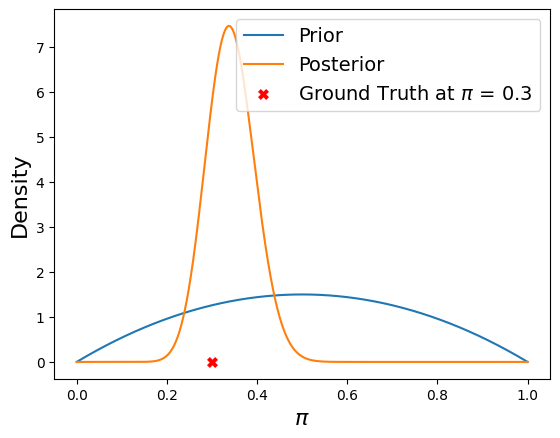

In [ ]:
# Evaluate prior and posterior at different values
pi_values = np.linspace(0, 1, 1000)
prior_eval = sp.beta(alpha_0, beta_0).pdf(pi_values)
posterior_eval = sp.beta(alpha_n, beta_n).pdf(pi_values)

# Plot prior and posterior
plt.plot(pi_values, prior_eval, label='Prior')
plt.plot(pi_values, posterior_eval, label='Posterior')
ax = plt.scatter(success_probability, 0, color='red', marker='X', s=60, linewidths=0.1, label='Ground Truth at $\pi$ = 0.3')
plt.xlabel('$\pi$', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.legend(fontsize=14)
plt.show()


We can see that the model has "learned", in the sense that the posterior is now more concentrated at the ground truth parameter $\pi=0.3$ which was used to simulate this data in the first place. We can verify that this model is well-calibrated by doing a posterior-predictive check.

### Posterior-predictive check

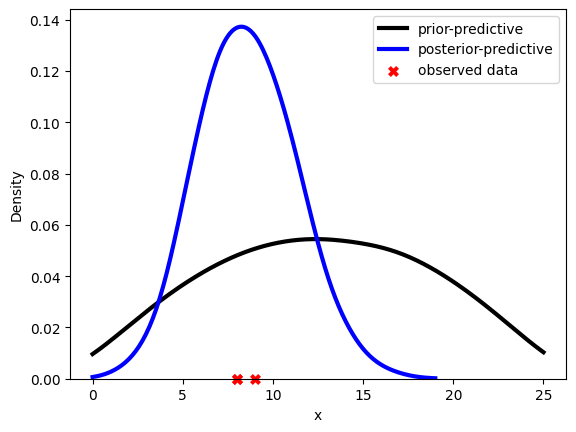

In [ ]:
beta_binomial_predictive(alpha=alpha_0, beta=beta_0,
                          label='prior-predictive', color='black', size=10000)
beta_binomial_predictive(alpha=alpha_n, beta=beta_n,
                        label='posterior-predictive', color='blue', size=10000)
plt.xlabel('x')
# Scatter plot of observed data to make sure it is well covered
ax = plt.scatter(x, np.zeros(x.shape), color='red', marker='X', s=60, linewidths=0.1, label='observed data')
plt.legend()
ax.set_clip_on(False)
plt.show()

We can see that the posterior-predictive distribution is more accurately centered around the observed data, hence implying that the model is well-calibrated. It is more obvious to see that the model is better calibrated by also plotting the credible intervals of the distribution.

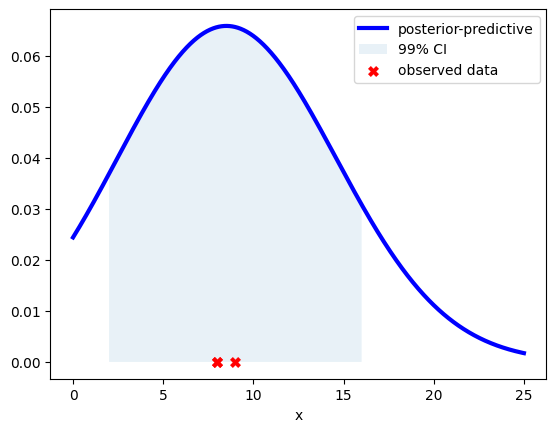

In [ ]:
# New function to obtain posterior-predictive with CI
def beta_binomial_credible_intervals(alpha, beta, label, color, level=0.1,
                                     size=10000):
  eval = np.linspace(0, 25, 1000)
  # Draw samples from beta distribution
  parameter_samples = np.random.beta(a=alpha, b=beta, size=size)
  # Simulate data from corresponding samples
  simulated_data = np.random.binomial(n=num_trials, p=parameter_samples)
  # KDE object
  kde = sp.gaussian_kde(simulated_data, bw_method=2)
  # Obtain percentiles
  credible_interval = (np.percentile(simulated_data, 100*(level/2)),
                       np.percentile(simulated_data, 100*(1-level/2)))
  # Second eval space
  eval_ci = np.linspace(credible_interval[0], credible_interval[1], 1000)
  values_ci = kde.pdf(eval_ci)
  # Plot CI
  values = kde.pdf(eval)
  plt.plot(eval, values, color=color, label=label, linewidth=3)
  plt.fill_between(eval_ci, values_ci, alpha=0.1, label=f'{int(100*(1-level))}% CI ')

# Example
beta_binomial_credible_intervals(alpha=alpha_n, beta=beta_n,
                                 label='posterior-predictive',
                                 color='blue', level=0.01,
                                 size=10000)
plt.xlabel('x')
# Scatter plot of observed data to make sure it is well covered
ax = plt.scatter(x, np.zeros(x.shape), color='red', marker='X', s=60,
                 linewidths=0.1, label='observed data')
plt.legend()
ax.set_clip_on(False)
plt.show()

### Asymptotic Normality

The Bernstein von-Mises theorem that asymptotically, the posterior distribution converges (in distribution) to a Gaussian random variable:

\begin{equation*}
\theta|x_{1:n} \overset{d}{\rightarrow} N(\widehat\theta_{\mathrm{MAP}}, I^{-1}(\widehat\theta_{\mathrm{MAP}}))
\end{equation*}

where $\widehat\theta_{\mathrm{MAP}}$ is the MAP estimate of the parameter and $I^{-1}(\widehat\theta_{\mathrm{MAP}})$ is the Bayesian informaton, which measures the curvature of posterior distribution.

We can verify the theorem by plotting the posterior and the Laplace approximation as a function of the number of samples.

**Exercise**: Derive the Laplace approximation based on a Beta posterior distribution to understand how it was computed in the following lines of code.

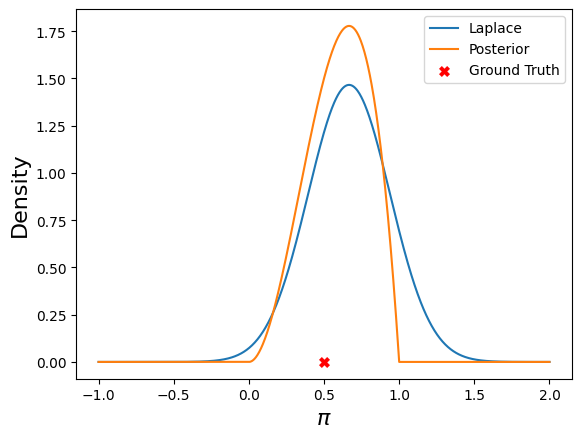

In [ ]:
# Number of samples in the dataset
num_samples = 3
num_trials = 1
success_probability = 0.5
alpha_0 = 1
beta_0 = 1

# Draw samples
x = generate_binomial_data(num_data=num_samples, num_trials=num_trials,
                           success_probability=success_probability)

# Obtain posterior hyperparameters
alpha_n = alpha_0 + np.sum(x)
beta_n = beta_0 + num_trials*x.shape[0] - np.sum(x)

# Formulate the Laplace approximation
post_rv = sp.beta(alpha_n, beta_n)
laplace_mean = (alpha_n-1)/(alpha_n+beta_n-2)
laplace_var = ((alpha_n-1)/(laplace_mean**2) + (beta_n-1)/((1-laplace_mean)**2))**(-1)

# Evaluate posterior and laplace
pi_values = np.linspace(-1, 2, 1000)
posterior_eval = sp.beta(alpha_n, beta_n).pdf(pi_values)
laplace_eval = sp.norm(laplace_mean, np.sqrt(laplace_var)).pdf(pi_values)

plt.plot(pi_values, laplace_eval, label='Laplace')
plt.plot(pi_values, posterior_eval, label='Posterior')
ax = plt.scatter(success_probability, 0, color='red', marker='X', s=60, linewidths=0.1, label='Ground Truth')
plt.xlabel('$\pi$', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.legend(fontsize=10)
plt.show()

We can also see the trend that as the number of observed data increases, the posterior variance also decreases, which is line with what theory suggests.